In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
trainData = datasets.CIFAR10(
    root="../data", 
    train=True, 
    transform=ToTensor(), 
    download=True,
    target_transform=None
)

testData = datasets.CIFAR10(
    root="../data", 
    train=False, 
    transform=ToTensor(), 
    download=True,
    target_transform=None
)

100%|██████████| 170M/170M [02:27<00:00, 1.15MB/s] 


In [17]:
image, label = trainData[865]
print(f"Image shape: {image.shape} | Label: {label}")

Image shape: torch.Size([3, 32, 32]) | Label: 3


In [18]:
class_names = trainData.classes
print(f"There are {len(class_names)} classes. Class names: {class_names}")


There are 10 classes. Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Text(0.5, 1.0, 'cat')

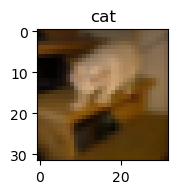

In [19]:
plt.figure(figsize=(1.7, 1.7))
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])

In [20]:
from torchvision import transforms

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
])

In [22]:
trainData = datasets.CIFAR10(
    root="../data", 
    train=True, 
    transform=transform, 
    download=True,
    target_transform=None
)

testData = datasets.CIFAR10(
    root="../data", 
    train=False, 
    transform=transform, 
    download=True,
    target_transform=None
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9886686..2.0942786].


Text(0.5, 1.0, 'frog')

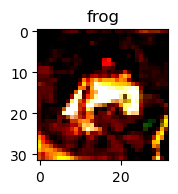

In [24]:
image, label = trainData[0]
image = image.permute(1, 2, 0)
plt.figure(figsize=(1.7, 1.7))
plt.imshow(image)
plt.title(class_names[label])

In [25]:
image

tensor([[[-1.0523e+00, -9.8178e-01, -7.6239e-01],
         [-1.3062e+00, -1.2395e+00, -1.0322e+00],
         [-1.1952e+00, -1.2072e+00, -1.0622e+00],
         ...,
         [ 5.1885e-01,  1.4557e-01, -8.7808e-02],
         [ 4.2363e-01,  3.2838e-02, -1.7775e-01],
         [ 3.6015e-01,  1.6733e-02, -1.6276e-01]],

        [[-1.7347e+00, -1.6582e+00, -1.4070e+00],
         [-1.9887e+00, -1.9803e+00, -1.7068e+00],
         [-1.7030e+00, -1.8514e+00, -1.7068e+00],
         ...,
         [-3.6613e-02, -5.6305e-01, -8.8232e-01],
         [-1.0009e-01, -6.4357e-01, -9.5727e-01],
         [-5.2483e-02, -5.7915e-01, -8.5233e-01]],

        [[-1.5919e+00, -1.5938e+00, -1.3920e+00],
         [-1.7347e+00, -1.8676e+00, -1.7068e+00],
         [-1.2110e+00, -1.5455e+00, -1.5869e+00],
         ...,
         [-1.1596e-01, -6.2747e-01, -9.5727e-01],
         [-8.4224e-02, -6.2747e-01, -9.5727e-01],
         [-2.5880e-01, -8.0462e-01, -1.0772e+00]],

        ...,

        [[ 1.3124e+00,  7.5756e-01, -2

In [26]:
from torch.utils.data import DataLoader

In [27]:
BATCH_SIZE = 32
trainDataloader = DataLoader(trainData, batch_size=BATCH_SIZE, shuffle=True)
testDataloader = DataLoader(testData, batch_size=BATCH_SIZE, shuffle=False)

In [28]:
print(f"Number of batches in train dataloader: {len(trainDataloader)}")

Number of batches in train dataloader: 1563


In [29]:
trainDataloader.dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616])
           )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9886686..2.0942786].


Text(0.5, 1.0, 'frog')

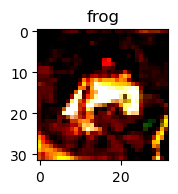

In [32]:
image, label = trainDataloader.dataset[0]
plt.figure(figsize=(1.7, 1.7))
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])

In [33]:
flattenModel = nn.Flatten()

flattenedImage = flattenModel(image)
print(f"Original image shape: {image.shape} | Flattened image shape: {flattenedImage.shape}")

Original image shape: torch.Size([3, 32, 32]) | Flattened image shape: torch.Size([3, 1024])


In [ ]:
nn.Linear(in_features=32, out_features=32, bias=True) 